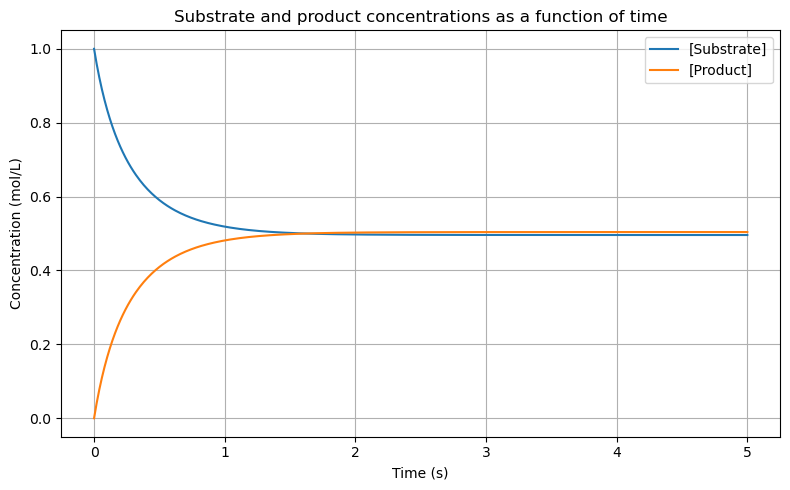

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

k1b = 10.0 # s^-1
k2f = 22.0 # s^-1
KmS = 210e-6 # mol/L
KmP = 97e-6 # mol/L
k1f = (k1b + k2f) / KmS  # L mol^-1 s^-1
k2b = (k1b + k2f) / KmP  # L mol^-1 s^-1

# Initial conditions in mol/L
S0 = 1.0 
P0 = 0.0 
E0 = 0.1 

def ode_system(t, y):
    S, P = y

    ES = E0 * (k1f * S + k2b * P) / (k1b + k2f + k1f * S + k2b * P)
    E = E0 - ES

    dSdt = -k1f * E * S + k1b * ES
    dPdt =  k2f * ES - k2b * E * P

    return [dSdt, dPdt]

t_span = (0.0, 5.0)
t_eval = np.linspace(0.0, 5.0, 500)

sol = solve_ivp(ode_system, t_span, [S0, P0], t_eval = t_eval, method = 'LSODA')

t = sol.t
S = sol.y[0]
P = sol.y[1]

# Recompute ES if needed
#ES = E0 * (k1f * S + k2b * P) / (k1b + k2f + k1f * S + k2b * P)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8,5))
plt.plot(t, S, label = "[Substrate]")
plt.plot(t, P, label = "[Product]")
plt.xlabel("Time (s)")
plt.ylabel("Concentration (mol/L)")
plt.title("Substrate and product concentrations as a function of time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()